# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker


## 1️) Load and Inspect the Dataset

In [4]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Double check some datatypes, and for nulls and duplicates:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [9]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [10]:
df.Segment.unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [11]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [12]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})

customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [13]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,7954360.98,923657.52
1,Corporate,4768494.07,622614.73
2,Home Office,2808676.56,403920.45


### What are the top 10 customers by total sales?

In [14]:
query2 = """ 
SELECT 
    o.customer_id,
    ROUND(SUM(od.sales),2) AS total_sales
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
GROUP BY o.customer_id
ORDER BY total_sales DESC
LIMIT 10
 """


result2 = pd.read_sql(query2, conn)
result2

,customer_id,total_sales
0,SM-20320,25043.05
1,TC-20980,19052.22
2,RB-19360,15117.34
3,TA-21385,14595.62
4,AB-10105,14473.57
5,KL-16645,14175.23
6,SC-20095,14142.33
7,HL-15040,12873.30
8,SE-20110,12209.44
9,CC-12370,12129.07


### Which product categories and subcategories are the most profitable overall?

In [15]:
query3 = """ 
SELECT 
    p.category,
    p.subcategory,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN products p ON od.product_id = p.product_id
GROUP BY p.category, p.subcategory
ORDER BY total_profit DESC
LIMIT 3
;

 """
result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,total_profit
0,Technology,Copiers,55617.82
1,Technology,Accessories,48359.05
2,Technology,Phones,46936.19


### What is the average discount given per category?

In [16]:
query4 = """ 

select p.category, avg(Discount) as avg_discount
from order_details od
join products p on od.product_id = p.product_id
group by p.category
order by p.category

 """
result4 = pd.read_sql(query4, conn)
result4

,category,avg_discount
0,Furniture,0.172514
1,Office Supplies,0.157000
2,Technology,0.132970


### Which states or regions contribute the most to total sales?

In [32]:
query5 = """ 
select strftime('%Y',o.order_date) as year, c.region, ROUND(SUM(od.sales), 2) AS total_sales
from orders o
join order_details od on o.order_id = od.order_id
join customers c on o.customer_id = c.customer_id
group by strftime('%Y',o.order_date), c.region
order by strftime('%Y',o.order_date), c.region
;
 """
result5 = pd.read_sql(query5, conn)
print (result5)


query5s = """ 
select c.state, ROUND(SUM(od.sales), 2) AS total_sales
from orders o
join order_details od on o.order_id = od.order_id
join customers c on o.customer_id = c.customer_id
group by c.state
order by total_sales DESC
limit 1
;
 """
result5s = pd.read_sql(query5s, conn)
print ("State that contributed the most is")
for v in result5s.values:
    print (f"{v[0]} : Total Sales {v[1]}")
print ("")

query5r = """ 
select c.region,  ROUND(SUM(od.sales), 2) AS total_sales
from orders o
join order_details od on o.order_id = od.order_id
join customers c on o.customer_id = c.customer_id
group by c.region
order by total_sales DESC
limit 1
;
 """
result5r = pd.read_sql(query5r, conn)
print ("Region that contributed the most is")
for v in result5r.values:
    print (f"{v[0]} : Total Sales {v[1]}")


    year   region  total_sales
0   2011  Central    740263.70
1   2011     East    849888.30
2   2011    South    598842.44
3   2011     West   1072981.96
4   2012  Central    782576.38
5   2012     East    837541.02
6   2012    South    569601.02
7   2012     West    971042.76
8   2013  Central   1073249.11
9   2013     East   1101494.65
10  2013    South    686494.91
11  2013     West   1384617.14
12  2014  Central   1159376.89
13  2014     East   1375374.96
14  2014    South    851499.16
15  2014     West   1476687.21
State that contributed the most is
California : Total Sales 2991943.64

Region that contributed the most is
West : Total Sales 4905329.07


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [18]:
query6 = """ 

select count(*) from orders
where ship_date > datetime(order_date,'+3 days')

 """
result6 = pd.read_sql(query6, conn)
result6

,count(*)
0,3391


### Which month or year had the highest total sales?

In [19]:
query7y = """ 

select strftime('%Y',o.order_date), ROUND(SUM(od.sales), 2) AS total_sales
from orders o
join order_details od on o.order_id = od.order_id
group by strftime('%Y',o.order_date)
order by total_sales DESC
limit 1
;

 """
result7y = pd.read_sql(query7y, conn)
for v in result7y.values: 
    print (f"Highest sales in Year {v[0]} : {v[1]}")

print ("")

query7m = """ 

select strftime('%m', o.order_date), ROUND(SUM(od.sales), 2) AS total_sales
from orders o
join order_details od on o.order_id = od.order_id
group by strftime('%m', o.order_date)
order by total_sales DESC
limit 1
;

 """
result7m = pd.read_sql(query7m, conn)
for v in result7m.values: 
    print (f"Highest sales in Month {v[0]} : {v[1]}")


Highest sales in Year 2014 : 733947.02

Highest sales in Month 11 : 349120.07


### What are the most frequently ordered products?

In [36]:
query8 = """ 

select p.product_id, count(*)
from order_details od
join products p on od.product_id = p.product_id
group by p.product_id 
order by p.product_id DESC
limit 1

 """
result8 = pd.read_sql(query8, conn)
result8

,product_id,count(*)
0,TEC-PH-10004977,9


### Which customers placed more than 5 orders total?

In [21]:
query9 = """ 

with cnt as 
    (
    select customer_id, count(*) as total_orders from orders
    group by customer_id )
select * from cnt where total_orders > 5
    order by total_orders
;

 """
result9 = pd.read_sql(query9, conn)
result9

,customer_id,total_orders
0,AA-10645,6
1,AR-10540,6
2,AS-10285,6
3,AT-10435,6
4,AZ-10750,6
...,...,...
459,NS-18640,13
460,PG-18820,13
461,SH-19975,13
462,ZC-21910,13


### What’s the profit margin (profit ÷ sales) by category or segment?

In [22]:
query10 = """ 

select p.category, ROUND (ROUND(SUM(od.profit), 2) / ROUND(SUM(od.sales), 2) ,2) *100 AS profit_margin 
from order_details od
join products p on od.product_id = p.product_id
group by p.category
order by p.category


 """
result10 = pd.read_sql(query10, conn)
result10

,category,profit_margin
0,Furniture,3.0
1,Office Supplies,17.0
2,Technology,17.0


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

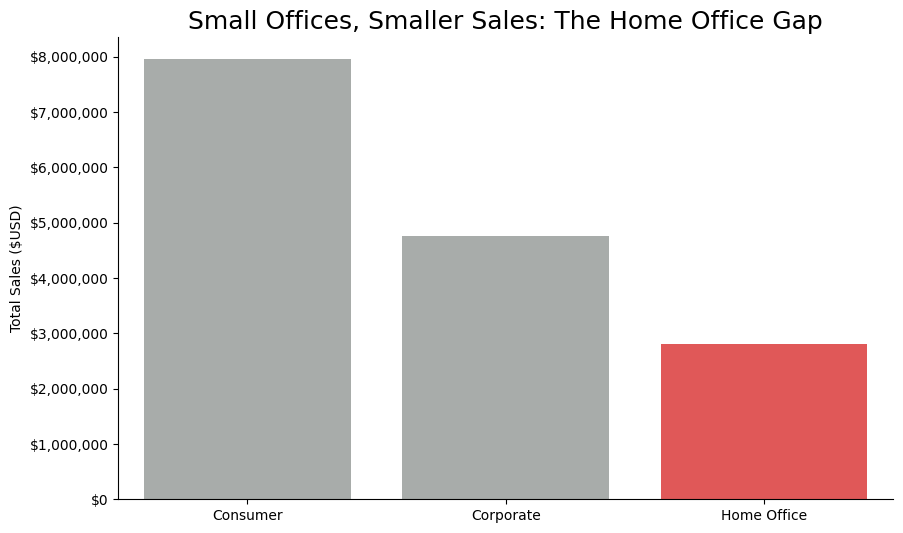

In [23]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


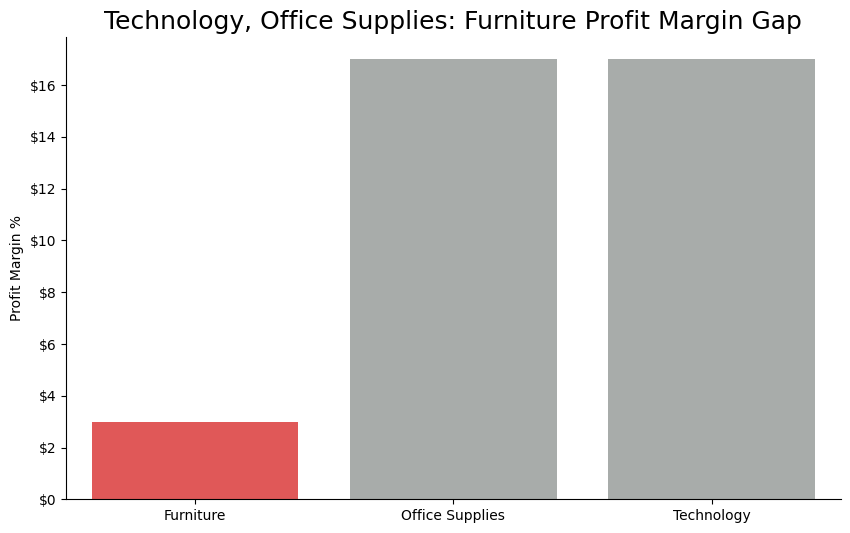

In [24]:
# visualization one code here

plt.figure(figsize=(10,6))
colors = ["#f74141", "#a7adaa", "#a7adaa"  ]
sns.barplot(result10, x='category', y='profit_margin', palette=colors, hue='category', legend=False)
plt.title('Technology, Office Supplies: Furniture Profit Margin Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Profit Margin %')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()



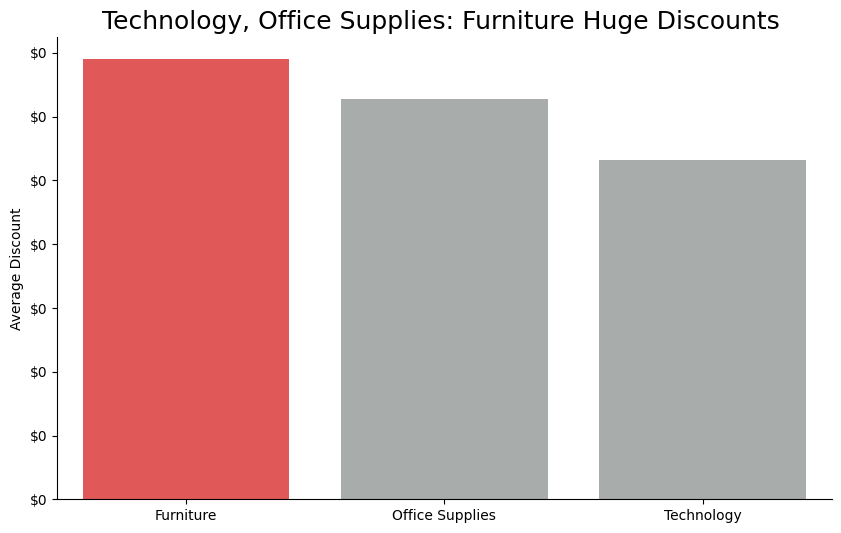

In [25]:
# visualization two code here

plt.figure(figsize=(10,6))
colors = ["#f74141", "#a7adaa", "#a7adaa" ]
sns.barplot(result4, x='category', y='avg_discount', palette=colors, hue='category', legend=False)
plt.title('Technology, Office Supplies: Furniture Huge Discounts ',fontsize=18)
plt.xlabel(None)
plt.ylabel('Average Discount')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()



In [53]:
result2

,customer_id,total_sales
0,SM-20320,25043.05
1,TC-20980,19052.22
2,RB-19360,15117.34
3,TA-21385,14595.62
4,AB-10105,14473.57
5,KL-16645,14175.23
6,SC-20095,14142.33
7,HL-15040,12873.30
8,SE-20110,12209.44
9,CC-12370,12129.07


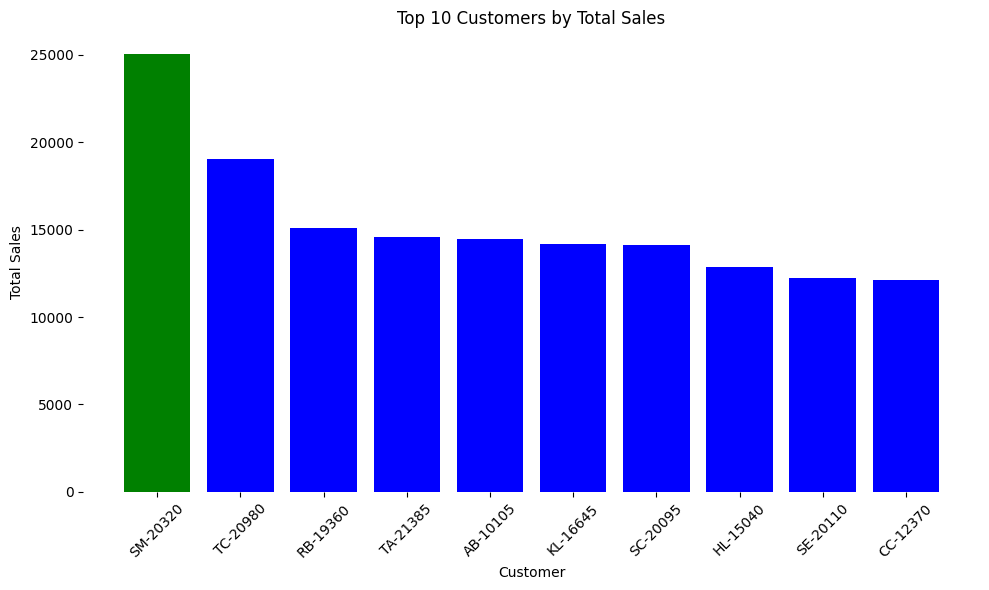

In [60]:
# visualization three code here

plt.figure(figsize=(10,6))

colors = ["blue"]*len(result2)

max_index = result2["total_sales"].idxmax()

highlight_position = result2["total_sales"].index.get_loc(max_index)

colors[highlight_position]= "green"


plt.bar(result2["customer_id"], result2["total_sales"], color = colors)

# ax is an object
ax= plt.gca( )
# not to show the border lines
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Customer")
plt.ylabel("Total Sales")
plt.title("Top 10 Customers by Total Sales")
plt.xticks(rotation=45, ha="center")
plt.tight_layout()
plt.show()

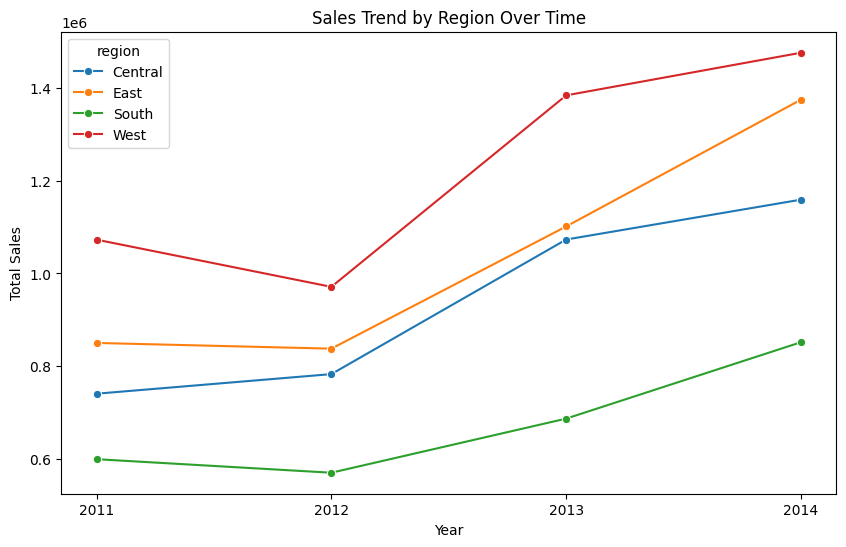

In [37]:
# visualization four code here
plt.figure(figsize=(10, 6))

sns.lineplot(data=result5,x="year",y="total_sales",hue="region",marker="o"
)

plt.title("Sales Trend by Region Over Time")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()
